In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("PrePlacement.csv")

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          215 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 25.3+ KB


In [4]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [5]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000


In [7]:
import seaborn as sns

C:\Users\pripo\AppData\Local\Temp\ipykernel_7648\2590864738.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["ssc_p"])


<Axes: xlabel='ssc_p', ylabel='Density'>

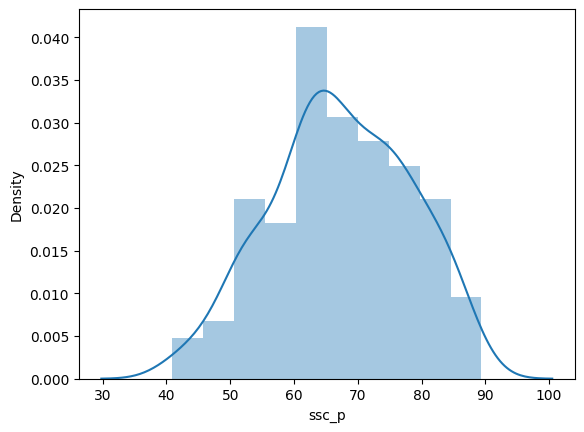

In [8]:
sns.distplot(dataset["ssc_p"])

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [41]:
# Function to get probability density. For that we need 3 parameters columnname,start range and end range
def get_pdf_probability(columnName,startrange,endrange):
    from matplotlib import pyplot  #import pyplot library from matplotlib
    from scipy.stats import norm #import norm library from scipy.stats
    import seaborn as sns #import seaborn
    ax=sns.distplot(columnName,kde=True,kde_kws={'color':'blue'},color='Green')  #seaborn distplot to see the column value distribution
    pyplot.axvline(startrange,color='red')  # vertical line for start range value
    pyplot.axvline(endrange,color='red')  # vertical line for end range value

    sample=columnName  # assigning column name value into a variable
    sample_mean = sample.mean() # Calculate Mean value and assign to a variable
    sample_std = sample.std() # calculate Std value and assign to a variale
    print ("Mean:%.3f, Standard_deviation:%.3f" %(sample_mean, sample_std)) # display mean and std

    dist=norm(sample_mean, sample_std)  # Calculate normal distribution and assign to a variable dist

    values=[value for value in range(startrange, endrange)]  #create a list of values between start range and end range
    probabilities = [dist.pdf(value) for value in values]  #calculate probabilities between values range
    prob=sum(probabilities)  # Add all probabilities and assign to a variable
    return prob  #return function

Mean:67.303, Standard_deviation:10.827


np.float64(0.3449514151280293)

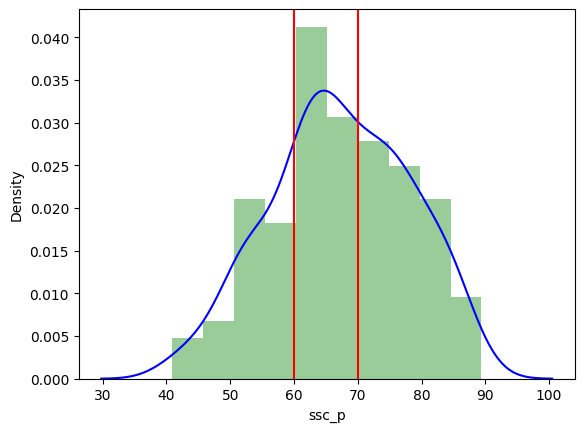

In [42]:
get_pdf_probability(dataset['ssc_p'],60,70)

In [47]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["ssc_p"])
ecdf(78)

np.float64(0.827906976744186)

In [50]:
def stdNBgraph(columnName):
    import seaborn as sns
    col_mean=columnName.mean()
    col_std=columnName.std()

    colvalues_list = [values for values in columnName]

    z_score = [((values-col_mean)/col_std)  for values in colvalues_list]

    sns.distplot(z_score, kde=True)

    sum(z_score)/len(z_score)
    

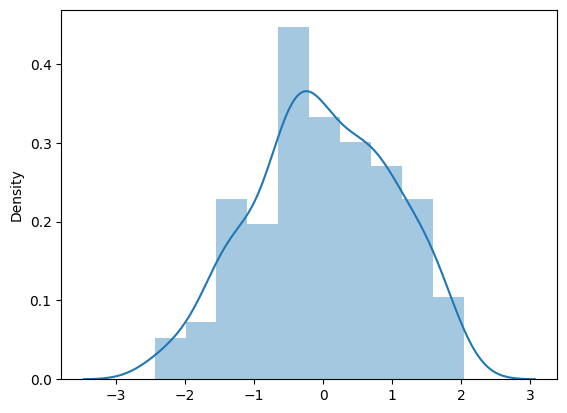

In [51]:
stdNBgraph(dataset['ssc_p'])